<a href="https://colab.research.google.com/github/kjahan/nlp_tips_and_trick/blob/main/notebooks/farsi_docs_translator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MT/LLM for Translation

Imagine we have a scanned doc in Persian (birth certificate or a degree). We want to translate it to Enlglish.

## Load test images

In [1]:
!mkdir data

In [2]:
import matplotlib.pyplot as plt

## Load image

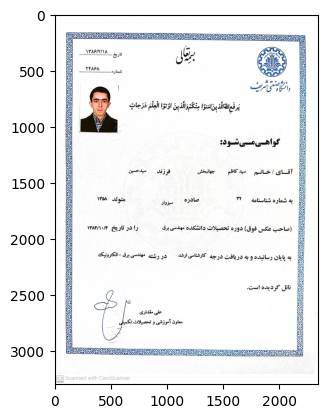

In [3]:
# Open the image file
img_1 = plt.imread("data/farsi_1.jpg")

# Display the image
plt.imshow(img_1)
plt.show()

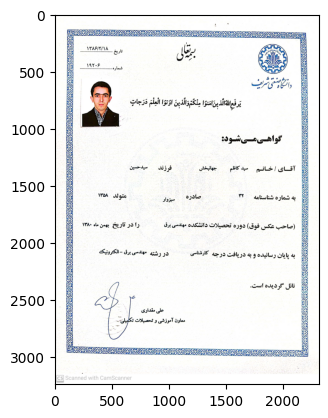

In [4]:
# Open the image file
img_2 = plt.imread("data/farsi_2.jpg")

# Display the image
plt.imshow(img_2)
plt.show()

In [5]:
images = [img_1, img_2]

## Install Terrasect

In [6]:
! apt install tesseract-ocr
! apt install libtesseract-dev
! pip install Pillow
! pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 3s (1,776 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

# Download Farsi font for OCR

https://github.com/kjahan/nlp_tips_and_trick/blob/main/notebooks/persian_textbook_image_to_text_converter.ipynb

https://github.com/kjahan/themis/blob/main/pipelines/disclosure_intel_pipeline.ipynb

https://stackoverflow.com/questions/62804846/extracting-persian-farsi-text-from-image-in-python



## Download fonts

Download fonts manually and load in the data folder. Don't use wget command since it doesnt download correctly.

https://github.com/tesseract-ocr/tessdata/blob/main/fas.traineddata

In [7]:
import pytesseract

In [8]:
!ls /usr/share/tesseract-ocr/4.00/tessdata/

configs  eng.traineddata  osd.traineddata  pdf.ttf  tessconfigs


In [9]:
!ls -l /usr/share/tesseract-ocr/4.00/tessdata/

total 14348
drwxr-xr-x 2 root root     4096 Dec 19 14:16 configs
-rw-r--r-- 1 root root  4113088 Sep 15  2017 eng.traineddata
-rw-r--r-- 1 root root 10562727 Sep 15  2017 osd.traineddata
-rw-r--r-- 1 root root      572 Feb  9  2022 pdf.ttf
drwxr-xr-x 2 root root     4096 Dec 19 14:16 tessconfigs


In [18]:
!cp /content/data/fas.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/
!cp /content/data/ara.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/

In [19]:
!ls -l /usr/share/tesseract-ocr/4.00/tessdata/

total 17340
-rw-r--r-- 1 root root  2494806 Dec 31 20:10 ara.traineddata
drwxr-xr-x 2 root root     4096 Dec 19 14:16 configs
-rw-r--r-- 1 root root  4113088 Sep 15  2017 eng.traineddata
-rw-r--r-- 1 root root   561272 Dec 31 20:10 fas.traineddata
-rw-r--r-- 1 root root 10562727 Sep 15  2017 osd.traineddata
-rw-r--r-- 1 root root      572 Feb  9  2022 pdf.ttf
drwxr-xr-x 2 root root     4096 Dec 19 14:16 tessconfigs


# Error

TesseractError: (1, 'Error opening data file /usr/share/tesseract-ocr/4.00/tessdata/fas.traineddata Please make sure the TESSDATA_PREFIX environment variable is set to your "tessdata" directory. Failed loading language \'fas\' Tesseract couldn\'t load any languages! Could not initialize tesseract.')

In [13]:
import tqdm

In [30]:
# go through each page image and run OCR
ocr_texts = []

with tqdm.tqdm(total=len(images)) as progress:
  for inx, image in enumerate(images):
    # Convert image to string
    # print(pytesseract.image_to_string(Image.open(disclouse_img)))
    # first two images are farsi
    #text = pytesseract.image_to_string(image, lang='fas', config='--psm 1')
    text = pytesseract.image_to_string(image, lang='ara')
    ocr_texts.append(text)
    break
    progress.update(1)

  0%|          | 0/2 [00:05<?, ?it/s]


In [31]:
test_inx = 0
print(ocr_texts[test_inx])

0
ََ
ي<
24
59
4
ِحآ
م
نْ

1
ن

 

 

 

 
    
  

2

َ عر 7
شماره تتمر.. يزمر رورمو 8
مر ل , 7
والئاءة “ورب 0
27
بر > رك » دادم ا ام ا 1 ل 8
ّ رق عالهالّذينَ نوا مِنْكُموَالَّذينَ اؤتوا العم دَرَجاتٍ ْ
2 8
000 شسود: 2

2 كواضى مى شود: 8
ار ل
ان حي الا سكا 0 ِّ ف 3 قل سك * 2
يه ً ادا حا 7 : ‎١‏ ا ٍِ 5 ‎١1‏ 7
2 به شماره شناسنامه صادده 0 بززار متولد َ
(صاحب عكس فوق) دوره تحصيلات دانشكده مهندسى برق زا در تاريخ ‎1788/1١‏ 2
به بايان رسانيده و به دريافت درجه كارشناسى ارشد .در رشته مهندسى برق - الكترونيكه 2
نار اء 2
ا نا يده أانتت. ا
5 نل كرد د
84 على مقدارى 2
2 معاون آموزشى و تحصيلات 7 5
3 2

1
بر

8 >
ل

الس لامتكا “مره مده



In [26]:
test_inx = 1
print(ocr_texts[test_inx])

ی



## OCR struggles with Persian!

Lets try this repo:

https://github.com/sepehrraisi/Persian-OCR

In [32]:
!git clone https://github.com/sepehrraisi/Persian-OCR

Cloning into 'Persian-OCR'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 172 (delta 10), reused 7 (delta 7), pack-reused 155
Receiving objects: 100% (172/172), 7.15 MiB | 13.09 MiB/s, done.
Resolving deltas: 100% (69/69), done.


In [33]:
!ls Persian-OCR

COPYING  Dictionary  Inputs  OCR  ocr.py  README  README.md  requirements.txt  textcleaner


In [34]:
!pip install -r Persian-OCR/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.5/770.5 kB 67.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 12.1 MB/s eta 0:00:00
  Created wheel for autocorrect: filename=autocorrect-2.6.1-py3-none-any.whl size=622364 sha256=6e08975e16b0b336049d645fb04f1feb9d3a1ca5f4fae2afd60c766dc8b6aab2
  Stored in directory: /root/.cache/pip/wheels/b5/7b/6d/b76b29ce11ff8e2521c8c7dd0e5bfee4fb1789d76193124343
Successfully built autocorrect
  Attempti

In [2]:
!python Persian-OCR/ocr.py -i data/farsi_1.jpg -o data/out.txt

In [3]:
with open('data/out.txt') as fp:
  txt = fp.read()

In [5]:
print(txt)

۹۹۹۹۹۹۹۹۹۹۹۹۹۹
:
در ۳/۸ و
موم ره
والا ی
ار . اون ما و رو ۰ ۳ سا ۳ ۰۴ ای ات
ای یرفعاللذینامنرا منکموالذین وتا الم رجات ۹ ۵
بح ی
شود: چ
لک
آقای /خانم ‏ میدکاظم ‏ جهانبخش فرزند میدحین
اک .
ی ۳۹
به شماره شناستامه ۰ ۳۲۰ صادده ‏ سبزوار متولد ۳۵۸ ی
صاحب عکس فوق دوره تحصیلات دانشکده مهندسی برق را در تاریخ ۳۸۴/۰/۴
به پایان رسانیده و به دریافت درجه کارشناسی ارشد . در رشته مهندسی برق ‏ الکترونیک
نا دیده است. و
ال ار
ا ی
اک
علی مقداری رن
ام معاون آموزشی و تحصیلات تکمیا
موی ی یج یج ره هگ



## Install Google translator
Google Translator
Ref: https://pypi.org/project/googletrans/

There was issues running Google translate. We fixed it by installing the release version. See below for some details on the issue:

https://stackoverflow.com/questions/21058935/python-json-loads-shows-valueerror-extra-data

https://github.com/kjahan/armory/blob/main/notebooks/google_translate.ipynb

In [6]:
!pip uninstall googletrans --y
!pip install googletrans==4.0.0rc1

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 9.9 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=e495320b1433479afca4e9485b8ddfac29452819e9677eef2ae4305c77c525f8
  Stored in directory: /root/.cache/pip/wheels/c0/59/9f/7372f0cf70160fe61b528532e1a7c8498c4becd6bcffb022de
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling c

## Setup Translator

In [7]:
from googletrans import Translator

translator = Translator()

## Language short names
https://meta.wikimedia.org/wiki/Template:List_of_language_names_ordered_by_code

In [ ]:
language_short_name = {'aa':'Afar','ab':'Abkhazian','af':'Afrikaans','ak':'Akan','sq':'Albanian','am':'Amharic','ar':'Arabic',
'an':'Aragonese', 'kohy':'Armenian','as':'Assamese','av':'Avaric','ae':'Avestan','ay':'Aymara','az':'Azerbaijani','ba':'Bashkir',
'bm':'Bambara','eu':'Basque','be':'Belarusian','bn':'Bengali','bh':'Bihari languages','bi':'Bislama','bo':'Tibetan','bs':'Bosnian',
'br':'Breton','bg':'Bulgarian','my':'Burmese','ca':'Catalan; Valencian','cs':'Czech','ch':'Chamorro','ce':'Chechen','zh':'Chinese',
'cu':'Church Slavic; Old Slavonic; Church Slavonic; Old Bulgarian; Old Church Slavonic','cv':'Chuvash','kw':'Cornish','co':'Corsican',
'cr':'Cree','cy':'Welsh','cs':'Czech','da':'Danish','de':'German','dv':'Divehi; Dhivehi; Maldivian','nl':'Dutch; Flemish','dz':'Dzongkha',
'el':'Greek-Modern (1453-)','en':'English','eo':'Esperanto','et':'Estonian','eu':'Basque','ee':'Ewe','fo':'Faroese','fa':'Persian',
'fj':'Fijian','fi':'Finnish','fr':'French','fy':'Western Frisian','ff':'Fulah','Ga':'Georgian','gd':'Gaelic; Scottish Gaelic','ga':'Irish',
'gl':'Galician','gv':'Manx','el':'Greek-Modern (1453-)','gn':'Guarani','gu':'Gujarati','ht':'Haitian; Haitian Creole','ha':'Hausa',
'he':'Hebrew','hz':'Herero','hi':'Hindi','ho':'Hiri Motu','hr':'Croatian','hu':'Hungarian','hy':'Armenian','ig':'Igbo','is':'Icelandic',
'io':'Ido','ii':'Sichuan Yi; Nuosu','iu':'Inuktitut','ie':'Interlingue; Occidental',
'ia':'Interlingua (International Auxiliary Language Association)','id':'Indonesian','ik':'Inupiaq','is':'Icelandic','it':'Italian',
'jv':'Javanese','ja':'Japanese','kl':'Kalaallisut; Greenlandic','kn':'Kannada','ks':'Kashmiri','ka':'Georgian','kr':'Kanuri','kk':'Kazakh',
'km':'Central Khmer','ki':'Kikuyu; Gikuyu','rw':'Kinyarwanda','ky':'Kirghiz; Kyrgyz','kv':'Komi','kg':'Kongo','ko':'Korean',
'kj':'Kuanyama; Kwanyama','ku':'Kurdish','lo':'Lao','la':'Latin','lv':'Latvian','li':'Limburgan; Limburger; Limburgish','ln':'Lingala',
'lt':'Lithuanian','lb':'Luxembourgish; Letzeburgesch','lu':'Luba-Katanga','lg':'Ganda','mk':'Macedonian','mh':'Marshallese',
'ml':'Malayalam','mi':'Maori','mr':'Marathi','ms':'Malay','Mi':'Micmac','mk':'Macedonian','mg':'Malagasy','mt':'Maltese',
'mn':'Mongolian','mi':'Maori','ms':'Malay','my':'Burmese','na':'Nauru','nv':'Navajo; Navaho','nr':'Ndebele-South; South Ndebele',
'nd':'Ndebele-North; North Ndebele','ng':'Ndonga','ne':'Nepali','nl':'Dutch; Flemish','nn':'Norwegian Nynorsk; Nynorsk:Norwegian',
'nb':'Bokmål-Norwegian; Norwegian Bokmål','no':'Norwegian','oc':'Occitan (post 1500)','oj':'Ojibwa','or':'Oriya','om':'Oromo',
'os':'Ossetian; Ossetic','pa':'Panjabi; Punjabi','fa':'Persian','pi':'Pali','pl':'Polish','pt':'Portuguese','ps':'Pushto; Pashto',
'qu':'Quechua','rm':'Romansh','ro':'Romanian; Moldavian; Moldovan','rn':'Rundi','ru':'Russian','sg':'Sango','sa':'Sanskrit',
'si':'Sinhala; Sinhalese','sk':'Slovak','sk':'Slovak','sl':'Slovenian','se':'Northern Sami','sm':'Samoan','sn':'Shona','sd':'Sindhi',
'so':'Somali','st':'Sotho-Southern','es':'Spanish; Castilian','sq':'Albanian','sc':'Sardinian','sr':'Serbian','ss':'Swati',
'su':'Sundanese','sw':'Swahili','sv':'Swedish','ty':'Tahitian','ta':'Tamil','tt':'Tatar','te':'Telugu','tg':'Tajik','tl':'Tagalog',
'th':'Thai','bo':'Tibetan','ti':'Tigrinya','to':'Tonga (Tonga Islands)','tn':'Tswana','ts':'Tsonga','tk':'Turkmen','tr':'Turkish',
'tw':'Twi','ug':'Uighur; Uyghur','uk':'Ukrainian','ur':'Urdu','uz':'Uzbek','ve':'Venda','vi':'Vietnamese','vo':'Volapük','cy':'Welsh',
'wa':'Walloon','wo':'Wolof','xh':'Xhosa','yi':'Yiddish','yo':'Yoruba','za':'Zhuang; Chuang','zh':'Chinese','zu':'Zulu'}

## Translate

In [8]:
text = "رئیس جمهوری در جلسه شورای‌عالی اشتغال با تاکید براینکه ایجاد اشتغال وظیفه ممتاز دستگاه‌های اجرایی و نهادها است، گفت: اگر ظرفیت‌های دولت در کنار بخش خصوصی و نهادهای انقلابی قرار گیرد، ایجاد بیش از یک میلیون فرصت شغلی در سال دور از دسترس نیست."

trans = translator.translate(text, dest='en').text
print(trans)

At the Supreme Employment Council meeting, the president emphasized that creating employment is a privileged task of executive agencies and institutions, saying that if the government's capacities are next to the private sector and revolutionary institutions, the creation of more than one million job opportunities in the year is not out of reach.


In [9]:
translated_text = translator.translate(txt, dest='en').text
print(translated_text)

1
:
At 1/4
Wax
Well
R .That's us and you and your
O Yar al -Zadin al -Makkamwalzin and Tha Rajat
Bah
Be: Ch
Stain
Mr. /Ms. Midkazam Jahanbakhsh
Ak.
1
Sabzevar Born in Sabzevar;
The above photo owner will study the Faculty of Electrical Engineering on 1/4/11
Finish and get a master's degree.In the field of electronics engineering
It is unhealthy.And
LR
Oh you
Ak
Ali some Ren
Umm Education and Studies Assistant
Hajj
